In [5]:
import warnings
from pathlib import Path

In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from incidencia_delictiva.config import (
    PROJ_ROOT, 
    DATA_DIR,
    PROCESSED_DATA_DIR
)

In [4]:
# configs
warnings.filterwarnings('ignore')

In [5]:
# scikit learn imports

In [6]:
temp_dir = DATA_DIR / "temp"
temp_dir.mkdir(exist_ok=True)

# Dataset para Modelado V2

...

Partimos del dataset baseline: 

In [7]:
dataset_baseline_path = PROCESSED_DATA_DIR / "dataset_baseline.parquet"
df = pd.read_parquet(dataset_baseline_path)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26038 entries, 0 to 26037
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   año                                      26038 non-null  int64  
 1   cvegeo                                   26038 non-null  str    
 2   total_delitos                            26038 non-null  float64
 3   poblacion_total                          26038 non-null  int64  
 4   indice_marginacion_normalizado_2020      26038 non-null  float64
 5   porcentaje_analfabetismo                 26038 non-null  float64
 6   porcentaje_sin_agua_entubada             26038 non-null  float64
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64
 8   fn_pobreza_porcentaje                    26017 non-null  float64
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64
 10  fn_vulnerable_ingresos_porcentaje        26017 non-null  

Cargamos los datos con geometría:

In [9]:
geodata_path = PROCESSED_DATA_DIR / "geo" / "geodata.parquet"
assert geodata_path.exists() and geodata_path.is_file()
gdf_geo = gpd.read_parquet(geodata_path)

In [10]:
gdf_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   cvegeo                     2475 non-null   str     
 1   cve_ent                    2475 non-null   str     
 2   cve_mun                    2475 non-null   str     
 3   nomgeo                     2475 non-null   str     
 4   nom_ent                    2475 non-null   str     
 5   cov_                       2475 non-null   int64   
 6   cov_id                     2475 non-null   int64   
 7   area                       2475 non-null   float64 
 8   perimeter                  2475 non-null   float64 
 9   geometry                   2475 non-null   geometry
 10  region                     2475 non-null   str     
 11  zona_metropolitana         2475 non-null   int64   
 12  zona_metropolitana_nombre  2475 non-null   str     
 13  es_frontera              

Seleccionamos las columnas útiles: 

In [11]:
columns_geo = [
    'cvegeo',
    'geometry',
]
gdf_geo = gdf_geo[columns_geo]

Unimos los datasets: 

In [12]:
gdf = df.merge(gdf_geo, on='cvegeo', how='left')

gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

In [13]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

Verificamos el CRS: 

In [14]:
gdf.crs

<Projected CRS: EPSG:6372>
Name: Mexico ITRF2008 / LCC
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Mexico - onshore and offshore.
- bounds: (-122.19, 12.1, -84.64, 32.72)
Coordinate Operation:
- name: Mexico LCC
- method: Lambert Conic Conformal (2SP)
Datum: Mexico ITRF2008
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

...

## Densidad poblacional

Definimos ...

In [15]:
gdf.columns

Index(['año', 'cvegeo', 'total_delitos', 'poblacion_total',
       'indice_marginacion_normalizado_2020', 'porcentaje_analfabetismo',
       'porcentaje_sin_agua_entubada', 'porcentaje_viviendas_hacinamiento',
       'fn_pobreza_porcentaje', 'fn_pobreza_extrema_porcentaje',
       'fn_vulnerable_ingresos_porcentaje',
       'fn_carencia_seguridad_social_porcentaje', 'fn_poblacion',
       'poblacion_urbano', 'nomgeo', 'area_km2', 'region',
       'zona_metropolitana', 'es_frontera', 'tasa_delitos', 'prop_urbano',
       'geometry'],
      dtype='str')

In [16]:
gdf['densidad_poblacional'] = (
    gdf['poblacion_total'] / gdf['area_km2']
)

In [17]:
gdf['densidad_poblacional'].describe()

count    26038.000000
mean       317.993063
std       1252.369230
min          0.105464
25%         20.144678
50%         57.726902
75%        151.621288
max      17623.951301
Name: densidad_poblacional, dtype: float64

...

## Features Geográficas

...

Usamos el paquete `libpysal` para la construicción de los vecinos por contigüidad espacial.

In [18]:
from libpysal.weights import Queen

In [19]:
Queen?

Init signature: Queen(polygons, **kw)
Docstring:     
Construct a weights object from a collection of pysal
polygons that share at least one vertex.

Parameters
----------
polygons    : list
              a collection of PySAL shapes to build weights from
ids         : list
              a list of names to use to build the weights
**kw        : keyword arguments
              optional arguments for :class:`pysal.weights.W`

See Also
--------
:class:`libpysal.weights.weights.W`
File:           ~/projects/criminalidad/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py
Type:           type
Subclasses:     

In [20]:
gdf_no_duplicates = gdf.drop_duplicates('cvegeo')

In [21]:
w = Queen.from_dataframe(gdf_no_duplicates)

Convertimos los resultados a tabla: 

In [22]:
neighbors_dict = w.neighbors

rows = []
for i, neighbors in neighbors_dict.items():
    cvegeo = gdf_no_duplicates.iloc[i]['cvegeo']
    for n in neighbors:
        vecino = gdf_no_duplicates.iloc[n]['cvegeo']
        rows.append((cvegeo, vecino))

df_vecinos = pd.DataFrame(rows, columns=['cvegeo', 'vecino'])

In [23]:
df_vecinos.head()

,cvegeo,vecino
0,21099,21046
1,21099,21063
2,21099,21177
3,21099,21110
4,21099,30006


In [24]:
df_vecinos.shape

(14454, 2)

In [25]:
df_vecinos.to_csv(temp_dir /"vecinos.csv")

In [26]:
# df_vecinos = pd.read_csv(temp_dir /"vecinos.csv", index_col=0)
# df_vecinos

Con lo anterior, por cada municipio tenemos asociado su conjunto de vecinos. 

### `lag_delitos`

...

Primero, contamos datos de los delitos ocurridos por cada año, entonces en cada municipio por cada año calculamos los delitos de sus vecinos. 

In [27]:
df_lag = gdf[['cvegeo', 'año', 'tasa_delitos']]

Unimos con el df de vecinos: 

In [28]:
df_lag = df_lag.merge(df_vecinos, on='cvegeo')
df_lag.head()

,cvegeo,año,tasa_delitos,vecino
0,21099,2016,677.670749,21046
1,21099,2016,677.670749,21063
2,21099,2016,677.670749,21177
3,21099,2016,677.670749,21110
4,21099,2016,677.670749,30006


Unimos con el df princiapal: 

In [29]:
df_lag = df_lag.merge(
    gdf[['cvegeo', 'año', 'tasa_delitos']],
    left_on=['vecino', 'año'],
    right_on=['cvegeo', 'año'],
    suffixes=('', '_vecino')
)

In [30]:
df_lag.head(30)

,cvegeo,año,tasa_delitos,vecino,cvegeo_vecino,tasa_delitos_vecino
0,21099,2016,677.670749,21046,21046,390.577322
1,21099,2016,677.670749,21063,21063,1442.503048
2,21099,2016,677.670749,21177,21177,292.200084
3,21099,2016,677.670749,21110,21110,609.246207
4,21099,2016,677.670749,30006,30006,264.069264
5,21099,2016,677.670749,21161,21161,463.588082
6,21099,2016,677.670749,30018,30018,252.780586
7,21106,2016,168.740772,21119,21119,1376.515073
8,21106,2016,168.740772,21019,21019,1045.890841
9,21106,2016,168.740772,21114,21114,1383.658131


El promedio de `tasa_delitos` por municipio en cada año: 

In [31]:
lag_delitos = (
    df_lag
    .groupby(['cvegeo', 'año'])['tasa_delitos_vecino']
    .mean()
    .reset_index()
    .rename(columns={'tasa_delitos_vecino': 'lag_delitos'})
)

In [32]:
lag_delitos.head(11)

,cvegeo,año,lag_delitos
0,01001,2015,758.760721
1,01001,2016,828.973001
2,01001,2017,1145.239246
3,01001,2018,1308.218111
4,01001,2019,1439.010794
5,01001,2020,1398.421488
6,01001,2021,1415.402215
7,01001,2022,1405.406086
8,01001,2023,1550.477461
9,01001,2024,1530.906971


Guardamos el dataset para futuras exploraciones: 

In [33]:
lag_delitos.to_csv(temp_dir / "lag_delitos.csv")

Hacemos el merge con el dataset principal:

In [34]:
gdf = gdf.merge(lag_delitos, on=['cvegeo', 'año'], how='left')
gdf.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,nomgeo,area_km2,region,zona_metropolitana,es_frontera,tasa_delitos,prop_urbano,geometry,densidad_poblacional,lag_delitos
0,2016,21099,140.0,20659,0.817433,11.906105,3.780352,34.689629,81.8,17.5,...,CaÃ±ada Morelos,243.637565,centro-sur,0,0,677.670749,0.378908,"POLYGON ((2985856.311 765456.226, 2985861.671 ...",84.793985,530.709228
1,2016,21106,72.0,42669,0.876713,7.350496,11.990227,26.213139,66.5,16.4,...,Ocoyucan,119.242818,centro-sur,1,0,168.740772,0.660103,"POLYGON ((2890527.077 780674.556, 2890529.358 ...",357.832871,831.959826
2,2016,21112,40.0,9350,0.815301,16.425406,6.572568,31.327641,84.3,25.0,...,Petlalcingo,232.404596,centro-sur,0,0,427.807487,0.348613,"POLYGON ((2937119.428 690457.114, 2937085.952 ...",40.231562,623.898672
3,2016,21124,44.0,15954,0.850825,11.514523,0.527473,38.301159,84.7,23.6,...,San Gabriel Chilac,108.976320,centro-sur,0,0,275.792905,0.828632,"POLYGON ((2993050.721 715814.146, 2993079.097 ...",146.398777,406.404139
4,2016,21130,24.0,3604,0.848144,10.243902,1.331853,27.074688,67.0,9.6,...,San Juan Atenco,95.786929,centro-sur,0,0,665.926748,NaN,"POLYGON ((2965034.08 797741.227, 2965785.758 7...",37.625176,723.417917


### `num_vecinos`

...

El computo es directo desde `df_vecinos`: 

In [35]:
num_vecinos = (
    df_vecinos
    .groupby('cvegeo')
    .size()
    .reset_index(name='num_vecinos')
)

num_vecinos.head()

,cvegeo,num_vecinos
0,01001,9
1,01002,8
2,01003,7
3,01004,3
4,01005,5


In [36]:
gdf = gdf.merge(num_vecinos, on='cvegeo', how='left')
gdf.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,area_km2,region,zona_metropolitana,es_frontera,tasa_delitos,prop_urbano,geometry,densidad_poblacional,lag_delitos,num_vecinos
0,2016,21099,140.0,20659,0.817433,11.906105,3.780352,34.689629,81.8,17.5,...,243.637565,centro-sur,0,0,677.670749,0.378908,"POLYGON ((2985856.311 765456.226, 2985861.671 ...",84.793985,530.709228,7
1,2016,21106,72.0,42669,0.876713,7.350496,11.990227,26.213139,66.5,16.4,...,119.242818,centro-sur,1,0,168.740772,0.660103,"POLYGON ((2890527.077 780674.556, 2890529.358 ...",357.832871,831.959826,6
2,2016,21112,40.0,9350,0.815301,16.425406,6.572568,31.327641,84.3,25.0,...,232.404596,centro-sur,0,0,427.807487,0.348613,"POLYGON ((2937119.428 690457.114, 2937085.952 ...",40.231562,623.898672,8
3,2016,21124,44.0,15954,0.850825,11.514523,0.527473,38.301159,84.7,23.6,...,108.976320,centro-sur,0,0,275.792905,0.828632,"POLYGON ((2993050.721 715814.146, 2993079.097 ...",146.398777,406.404139,4
4,2016,21130,24.0,3604,0.848144,10.243902,1.331853,27.074688,67.0,9.6,...,95.786929,centro-sur,0,0,665.926748,NaN,"POLYGON ((2965034.08 797741.227, 2965785.758 7...",37.625176,723.417917,5


### `promedio_vecinos`

...

### Distancia a frontera

Primero, es necesario corregir el dataset actual, ya que los municipios marcados como frontera son aquellos que pertenecen a un estado frontera y lo conveniente sería marcar únicamente los municipios que colindan con los paises fronterizos. 

La estrategia es descargar un mapamundi, filtrar los paises con frontera en México y cruzar los municipios frontera con estos.

In [37]:
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [38]:
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


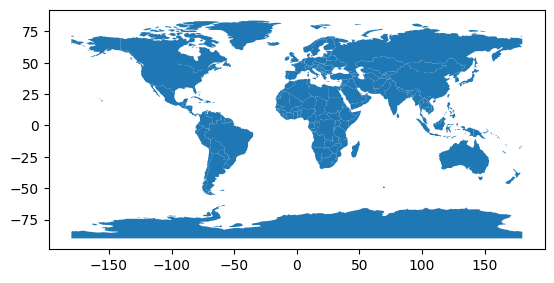

In [39]:
world.plot(); 

In [40]:
'NAME' in world.columns.tolist()

True

In [41]:
'Mexico' in world.NAME.unique()

True

México: 

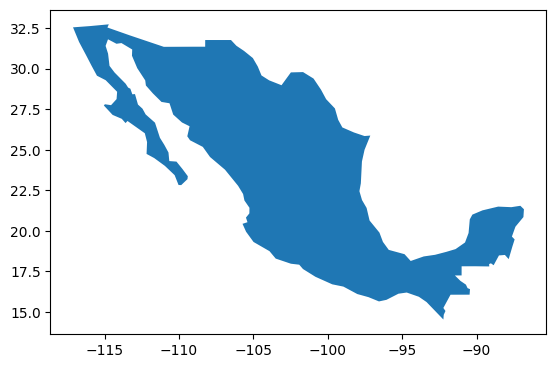

In [42]:
mexico = world[world.NAME == 'Mexico']
mexico.plot(); 

USA (frontera norte): 

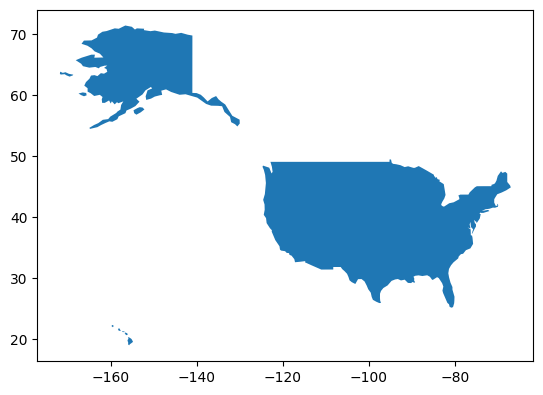

In [43]:
usa = world[world.NAME == 'United States of America']
usa.plot(); 

La frontera sur: Guatemala, Belize

In [44]:
guatemala = world[world.NAME == 'Guatemala']
belize = world[world.NAME == 'Belize']

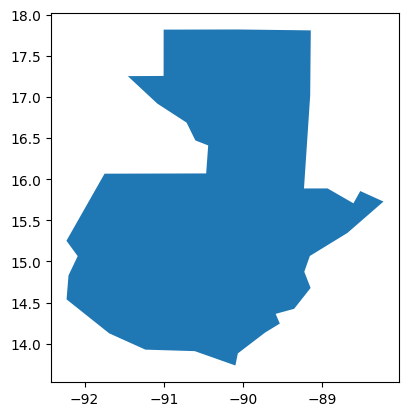

In [45]:
guatemala.plot(); 

<Axes: >

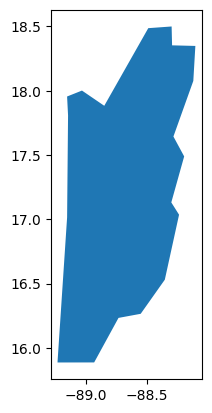

In [46]:
belize.plot()

Las lineas de la frontera norte: 

In [47]:
frontera_norte = mexico.geometry.boundary.intersection(usa.geometry.unary_union)

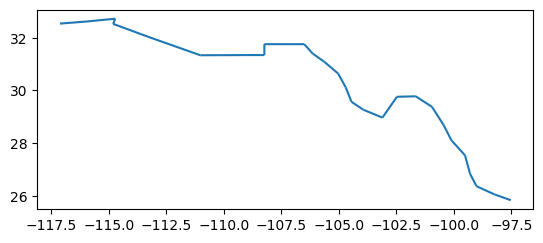

In [48]:
frontera_norte.plot(); 

La frontera sur: 

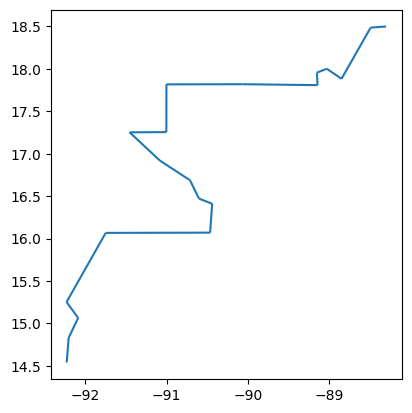

In [49]:
frontera_sur = mexico.geometry.boundary.intersection(
    guatemala.geometry.unary_union.union(belize.geometry.unary_union)
)

frontera_sur.plot();

In [51]:
municipios = gpd.read_parquet(PROCESSED_DATA_DIR / "geo" / "geodata.parquet")
municipios.head()

,cvegeo,cve_ent,cve_mun,nomgeo,nom_ent,cov_,cov_id,area,perimeter,geometry,region,zona_metropolitana,zona_metropolitana_nombre,es_frontera,area_km2
0,01008,01,008,San JosÃ© de Gracia,Aguascalientes,0,1,85779.057424,181537.599566,"POLYGON ((2463679.819 1122454.043, 2463636.551...",centro-norte,0,Unknown,0,857.790574
1,01009,01,009,TepezalÃ¡,Aguascalientes,1,2,22966.101228,89329.531705,"POLYGON ((2483386.269 1147520.506, 2483452.328...",centro-norte,0,Unknown,0,229.661012
2,01010,01,010,El Llano,Aguascalientes,2,3,50405.098875,144866.490025,"POLYGON ((2510504.977 1104537.995, 2511266.668...",centro-norte,0,Unknown,0,504.050989
3,01011,01,011,San Francisco de los Romo,Aguascalientes,3,4,13777.017628,103689.065527,"POLYGON ((2485534.556 1117425.794, 2485536.613...",centro-norte,0,Unknown,0,137.770176
4,01001,01,001,Aguascalientes,Aguascalientes,4,5,116635.924756,256631.025245,"POLYGON ((2489959.178 1111683.059, 2489874.765...",centro-norte,1,tijuana,0,1166.359248


In [52]:
municipios = municipios.to_crs(mexico.crs)

In [53]:
buffer_dist = 0.1 

municipios_norte = municipios[municipios.intersects(frontera_norte.buffer(buffer_dist).unary_union)]
municipios_sur = municipios[municipios.intersects(frontera_sur.buffer(buffer_dist).unary_union)]

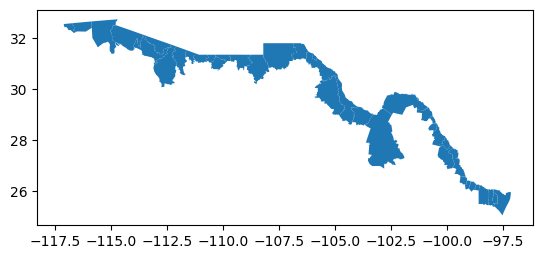

In [54]:
municipios_norte.plot(); 

<Axes: >

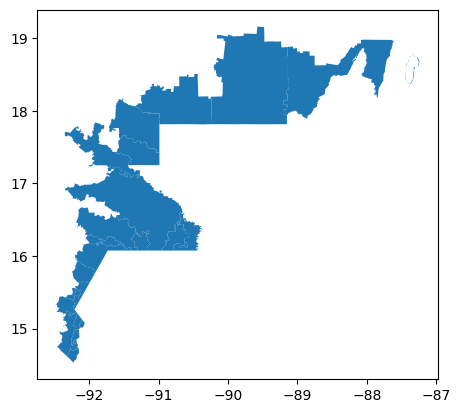

In [55]:
municipios_sur.plot()

In [56]:
municipios_frontera = (
    municipios_norte.cvegeo.tolist() + 
    municipios_sur.cvegeo.tolist()
)
print(len(municipios_frontera))

67


In [57]:
gdf = gdf.drop(columns='es_frontera')

In [58]:
67*11  # 11 anios

737

In [59]:
gdf['es_frontera'] = np.where(gdf.cvegeo.isin(municipios_frontera), 1,0)

In [60]:
gdf.shape

(26038, 25)

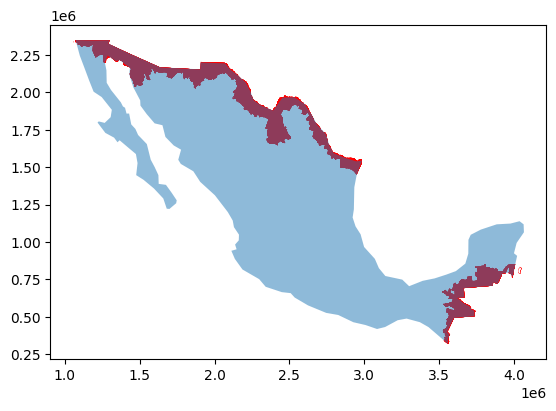

In [69]:
ax = gdf[gdf["es_frontera"] == 1].plot(color='red')
mexico.to_crs(gdf.crs).plot(ax=ax,alpha=0.5); 

Los resultados son exitosos. 

In [71]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 26038 entries, 0 to 26037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   año                                      26038 non-null  int64   
 1   cvegeo                                   26038 non-null  str     
 2   total_delitos                            26038 non-null  float64 
 3   poblacion_total                          26038 non-null  int64   
 4   indice_marginacion_normalizado_2020      26038 non-null  float64 
 5   porcentaje_analfabetismo                 26038 non-null  float64 
 6   porcentaje_sin_agua_entubada             26038 non-null  float64 
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64 
 8   fn_pobreza_porcentaje                    26017 non-null  float64 
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64 
 10  fn_vulnerable_ingresos_por

Con lo anterior, procedemos con el computo de la distancia a frontera de cada municipio en México. 

Los centroides: 

In [73]:
gdf_centroids = gdf.drop_duplicates('cvegeo').copy()
gdf_centroids['centroid'] = gdf_centroids.geometry.centroid

Separamos los municipios frontera: 

In [74]:
frontera = gdf_centroids[gdf_centroids['es_frontera'] == 1]
no_frontera = gdf_centroids[gdf_centroids['es_frontera'] == 0]

Definimos la función para computar la distancia mínima de un municipio a otro que se encuentre en alguna frontera. 

In [75]:
from shapely.ops import nearest_points

def min_distance(point, others):
    return others.distance(point).min()

In [79]:
no_frontera['distancia_frontera_m'] = no_frontera['centroid'].apply(
    lambda x: min_distance(x, frontera['centroid'])
)

In [80]:
dist_frontera = no_frontera[['cvegeo', 'distancia_frontera_m']]
dist_frontera

,cvegeo,distancia_frontera_m
0,21099,610696.980889
1,21106,706923.975188
2,21112,650645.795309
3,21124,597921.441241
4,21130,631586.435386
...,...,...
9214,07121,121812.925215
9215,07122,115642.636663
9216,07123,117764.403820
11556,17034,779658.434271


Unimos con el dataset principal: 

In [81]:
gdf = gdf.merge(dist_frontera, on='cvegeo', how='left')

In [85]:
gdf.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,region,zona_metropolitana,tasa_delitos,prop_urbano,geometry,densidad_poblacional,lag_delitos,num_vecinos,es_frontera,distancia_frontera_m
0,2016,21099,140.0,20659,0.817433,11.906105,3.780352,34.689629,81.8,17.5,...,centro-sur,0,677.670749,0.378908,"POLYGON ((2985856.311 765456.226, 2985861.671 ...",84.793985,530.709228,7,0,610696.980889
1,2016,21106,72.0,42669,0.876713,7.350496,11.990227,26.213139,66.5,16.4,...,centro-sur,1,168.740772,0.660103,"POLYGON ((2890527.077 780674.556, 2890529.358 ...",357.832871,831.959826,6,0,706923.975188
2,2016,21112,40.0,9350,0.815301,16.425406,6.572568,31.327641,84.3,25.0,...,centro-sur,0,427.807487,0.348613,"POLYGON ((2937119.428 690457.114, 2937085.952 ...",40.231562,623.898672,8,0,650645.795309
3,2016,21124,44.0,15954,0.850825,11.514523,0.527473,38.301159,84.7,23.6,...,centro-sur,0,275.792905,0.828632,"POLYGON ((2993050.721 715814.146, 2993079.097 ...",146.398777,406.404139,4,0,597921.441241
4,2016,21130,24.0,3604,0.848144,10.243902,1.331853,27.074688,67.0,9.6,...,centro-sur,0,665.926748,NaN,"POLYGON ((2965034.08 797741.227, 2965785.758 7...",37.625176,723.417917,5,0,631586.435386


De manera similar, podemos calcular la distancia a la zona metropolitana más cercana: 

In [86]:
zm = gdf_centroids[gdf_centroids['zona_metropolitana'] == 1]
no_zm = gdf_centroids.copy()

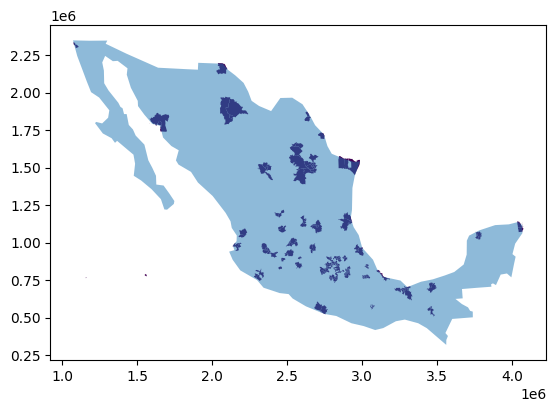

In [89]:
ax = zm.plot(column='zona_metropolitana')
mexico.to_crs(zm.crs).plot(ax=ax, alpha=0.5); 

In [93]:
no_zm['distancia_zm_m'] = no_zm['centroid'].apply(
    lambda x: min_distance(x, zm['centroid'])
)

In [94]:
gdf = gdf.merge(
    no_zm[['cvegeo', 'distancia_zm_m']],
    on='cvegeo',
    how='left'
)

In [97]:
gdf.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,tasa_delitos,prop_urbano,geometry,densidad_poblacional,lag_delitos,num_vecinos,es_frontera,distancia_frontera_m,distancia_zm,distancia_zm_m
0,2016,21099,140.0,20659,0.817433,11.906105,3.780352,34.689629,81.8,17.5,...,677.670749,0.378908,"POLYGON ((2985856.311 765456.226, 2985861.671 ...",84.793985,530.709228,7,0,610696.980889,26172.062913,26172.062913
1,2016,21106,72.0,42669,0.876713,7.350496,11.990227,26.213139,66.5,16.4,...,168.740772,0.660103,"POLYGON ((2890527.077 780674.556, 2890529.358 ...",357.832871,831.959826,6,0,706923.975188,0.000000,0.000000
2,2016,21112,40.0,9350,0.815301,16.425406,6.572568,31.327641,84.3,25.0,...,427.807487,0.348613,"POLYGON ((2937119.428 690457.114, 2937085.952 ...",40.231562,623.898672,8,0,650645.795309,104367.062589,104367.062589
3,2016,21124,44.0,15954,0.850825,11.514523,0.527473,38.301159,84.7,23.6,...,275.792905,0.828632,"POLYGON ((2993050.721 715814.146, 2993079.097 ...",146.398777,406.404139,4,0,597921.441241,57130.990096,57130.990096
4,2016,21130,24.0,3604,0.848144,10.243902,1.331853,27.074688,67.0,9.6,...,665.926748,NaN,"POLYGON ((2965034.08 797741.227, 2965785.758 7...",37.625176,723.417917,5,0,631586.435386,40664.779096,40664.779096


In [98]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 26038 entries, 0 to 26037
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   año                                      26038 non-null  int64   
 1   cvegeo                                   26038 non-null  str     
 2   total_delitos                            26038 non-null  float64 
 3   poblacion_total                          26038 non-null  int64   
 4   indice_marginacion_normalizado_2020      26038 non-null  float64 
 5   porcentaje_analfabetismo                 26038 non-null  float64 
 6   porcentaje_sin_agua_entubada             26038 non-null  float64 
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64 
 8   fn_pobreza_porcentaje                    26017 non-null  float64 
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64 
 10  fn_vulnerable_ingresos_por

In [99]:
gdf.crs

<Projected CRS: EPSG:6372>
Name: Mexico ITRF2008 / LCC
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Mexico - onshore and offshore.
- bounds: (-122.19, 12.1, -84.64, 32.72)
Coordinate Operation:
- name: Mexico LCC
- method: Lambert Conic Conformal (2SP)
Datum: Mexico ITRF2008
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

---

In [8]:
dataset_geoespatial_dir = PROCESSED_DATA_DIR / "dataset_geospatial"

In [12]:
gdfs = []
for item in dataset_geoespatial_dir.iterdir(): 
    gdfs.append(gpd.read_parquet(item))

In [16]:
gdf = pd.concat(gdfs)

In [17]:
gdf.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,tasa_delitos,prop_urbano,geometry,es_frontera,densidad_poblacional,num_vecinos,lag_delitos,lag_marginacion,distancia_frontera,distancia_zm
0,2016,21099,140.0,20659,0.817433,11.906105,3.780352,34.689629,81.8,17.5,...,677.670749,0.378908,"POLYGON ((2985856.311 765456.226, 2985861.671 ...",0,84.793985,7,530.709228,0.832401,610696.980889,26172.062913
1,2016,21106,72.0,42669,0.876713,7.350496,11.990227,26.213139,66.5,16.4,...,168.740772,0.660103,"POLYGON ((2890527.077 780674.556, 2890529.358 ...",0,357.832871,6,831.959826,0.872643,706923.975188,0.000000
2,2016,21112,40.0,9350,0.815301,16.425406,6.572568,31.327641,84.3,25.0,...,427.807487,0.348613,"POLYGON ((2937119.428 690457.114, 2937085.952 ...",0,40.231562,8,623.898672,0.838420,650645.795309,104367.062589
3,2016,21124,44.0,15954,0.850825,11.514523,0.527473,38.301159,84.7,23.6,...,275.792905,0.828632,"POLYGON ((2993050.721 715814.146, 2993079.097 ...",0,146.398777,4,406.404139,0.856268,597921.441241,57130.990096
4,2016,21130,24.0,3604,0.848144,10.243902,1.331853,27.074688,67.0,9.6,...,665.926748,NaN,"POLYGON ((2965034.08 797741.227, 2965785.758 7...",0,37.625176,5,723.417917,0.855477,631586.435386,40664.779096


In [18]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 26038 entries, 0 to 1037
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   año                                      26038 non-null  int64   
 1   cvegeo                                   26038 non-null  str     
 2   total_delitos                            26038 non-null  float64 
 3   poblacion_total                          26038 non-null  int64   
 4   indice_marginacion_normalizado_2020      26038 non-null  float64 
 5   porcentaje_analfabetismo                 26038 non-null  float64 
 6   porcentaje_sin_agua_entubada             26038 non-null  float64 
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64 
 8   fn_pobreza_porcentaje                    26017 non-null  float64 
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64 
 10  fn_vulnerable_ingresos_porcentaj